# Intent–Behavior Deviation in Smart Contracts
## Notebook 3: Tier 3 — Deep MLP (5-Layer, Tuned)
**Architecture:** 398→512→256→128→64→1 · BatchNorm · Dropout · Gradient Clipping · CosineAnnealingLR  
**Includes:** Hyperparameter sweep · Threshold tuning · Calibration plot · Error analysis  
**Epochs:** 50–200 (patience=15)

In [1]:
import io, requests

# ─────────────────────────────────────────────────────────────────────────────
# Load dataset directly from GitHub (raw CSV)
# ─────────────────────────────────────────────────────────────────────────────
GITHUB_RAW_URL = (
    'https://raw.githubusercontent.com/AbrarBb/Intent-Behavior-Deviation-Dataset'
    '/main/ml_dataset_verified_full.csv'
)

print('Downloading dataset from GitHub...')
response = requests.get(GITHUB_RAW_URL)
response.raise_for_status()
CSV_PATH = io.StringIO(response.text)
print('✅ Dataset loaded successfully from GitHub')

✅ Dataset loaded successfully from GitHub


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, json, itertools, warnings
warnings.filterwarnings('ignore')
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics         import (f1_score, roc_auc_score, roc_curve,
                                      confusion_matrix, classification_report,
                                      precision_recall_curve, average_precision_score,
                                      precision_score, recall_score)
from sklearn.calibration import calibration_curve

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
plt.rcParams['figure.dpi']=120
COLORS=['#2ec7cc','#db70c0']
SEED=42; torch.manual_seed(SEED); np.random.seed(SEED)

Device: cuda


In [3]:
import os
try:
    assert os.path.exists('dataset_full.csv')
    df_full=pd.read_csv('dataset_full.csv')
    df_bal =pd.read_csv('dataset_balanced.csv')
    with open('col_info.json') as f: col_info=json.load(f)
    HYBRID_COLS=col_info['hybrid_cols']; LABEL_COL=col_info['label_col']
except:
    df_full=pd.read_csv(CSV_PATH)
    EMB_COLS=[c for c in df_full.columns if c.startswith('emb_')]
    BEHAV_COLS=['owner_withdraw','emergency_withdraw','unrestricted_mint',
                'regex_owner_withdraw','regex_emergency_withdraw','regex_unrestricted_mint',
                'slither_ok','slither_high_count','slither_arbitrary_send',
                'slither_suicidal','slither_unchecked_lowlevel',
                'slither_controlled_delegatecall','slither_delegatecall_loop',
                'slither_ownerish_any']
    HYBRID_COLS=EMB_COLS+BEHAV_COLS; LABEL_COL='target'
    min_c=df_full[LABEL_COL].value_counts().min()
    df_bal=pd.concat([df_full[df_full[LABEL_COL]==0].sample(min_c,random_state=SEED),
                       df_full[df_full[LABEL_COL]==1].sample(min_c,random_state=SEED)]).reset_index(drop=True)

INPUT_DIM=len(HYBRID_COLS)
X_full=StandardScaler().fit_transform(df_full[HYBRID_COLS].values); y_full=df_full[LABEL_COL].values
X_bal =StandardScaler().fit_transform(df_bal[HYBRID_COLS].values);  y_bal =df_bal[LABEL_COL].values
print(f'Full:{X_full.shape}  Balanced:{X_bal.shape}  Features:{INPUT_DIM}')

Full:(3324, 398)  Balanced:(2044, 398)  Features:398


---
## Deep MLP Architecture (5-Layer)

In [4]:
class DeepMLP(nn.Module):
    def __init__(self,input_dim,dropout=0.3):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(input_dim,512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512,256),        nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256,128),        nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128,64),         nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout/2),
            nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

print(DeepMLP(INPUT_DIM))
total_params=sum(p.numel() for p in DeepMLP(INPUT_DIM).parameters())
print(f'Total parameters: {total_params:,}')

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=398, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.15, inplace=False)
    (16): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 378,753


In [5]:
def train_deep(X_tr,y_tr,X_vl,y_vl,input_dim,
                dropout=0.3,lr=0.001,batch_size=32,max_epochs=200,patience=15):
    pos_w=torch.tensor([(y_tr==0).sum()/(y_tr==1).sum()],dtype=torch.float32).to(device)
    model=DeepMLP(input_dim,dropout).to(device)
    opt=optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=max_epochs)
    dl=DataLoader(TensorDataset(torch.tensor(X_tr,dtype=torch.float32),
                                 torch.tensor(y_tr,dtype=torch.float32)),
                  batch_size=batch_size,shuffle=True)
    Xvl_t=torch.tensor(X_vl,dtype=torch.float32).to(device)
    yvl_t=torch.tensor(y_vl,dtype=torch.float32).to(device)
    hist={'train_loss':[],'val_loss':[],'val_f1':[],'val_auc':[],'lr':[]}
    best_f1,best_st,wait=0,None,0
    for ep in range(max_epochs):
        model.train(); tl=0
        for xb,yb in dl:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad()
            loss=nn.functional.binary_cross_entropy_with_logits(model(xb),yb,pos_weight=pos_w)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); tl+=loss.item()*len(xb)
        sched.step()
        model.eval()
        with torch.no_grad():
            vl_out=model(Xvl_t)
            vl_loss=nn.functional.binary_cross_entropy_with_logits(vl_out,yvl_t,pos_weight=pos_w).item()
            vp=torch.sigmoid(vl_out).cpu().numpy()
            vf=f1_score(y_vl,(vp>0.5).astype(int),average='macro')
            va=roc_auc_score(y_vl,vp)
        hist['train_loss'].append(tl/len(X_tr)); hist['val_loss'].append(vl_loss)
        hist['val_f1'].append(vf); hist['val_auc'].append(va)
        hist['lr'].append(opt.param_groups[0]['lr'])
        if vf>best_f1: best_f1=vf; best_st={k:v.clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait+=1
            if wait>=patience: break
    model.load_state_dict(best_st)
    return model,hist
print('Deep training function ready')

Deep training function ready


---
## Hyperparameter Sweep

In [6]:
X_tr_sw,X_vl_sw,y_tr_sw,y_vl_sw=train_test_split(X_full,y_full,test_size=0.2,stratify=y_full,random_state=SEED)
hp_grid={'lr':[0.001,0.0005,0.0001],'dropout':[0.2,0.3,0.4],'batch':[32,64]}
sweep_res=[]
total=len(hp_grid['lr'])*len(hp_grid['dropout'])*len(hp_grid['batch'])
print(f'Running {total} HP configs...')
for i,(lr,dp,bs) in enumerate(itertools.product(hp_grid['lr'],hp_grid['dropout'],hp_grid['batch'])):
    m,_=train_deep(X_tr_sw,y_tr_sw,X_vl_sw,y_vl_sw,INPUT_DIM,
                    dropout=dp,lr=lr,batch_size=bs,max_epochs=80,patience=10)
    m.eval()
    with torch.no_grad():
        p=torch.sigmoid(m(torch.tensor(X_vl_sw,dtype=torch.float32).to(device))).cpu().numpy()
    f=f1_score(y_vl_sw,(p>0.5).astype(int),average='macro')
    a=roc_auc_score(y_vl_sw,p)
    sweep_res.append({'lr':lr,'dropout':dp,'batch':bs,'f1':f,'auc':a})
    print(f'  [{i+1}/{total}] lr={lr} dp={dp} bs={bs} → F1={f:.4f}')
df_sweep=pd.DataFrame(sweep_res).sort_values('f1',ascending=False)
best_hp=df_sweep.iloc[0]
BEST_LR=float(best_hp.lr); BEST_DP=float(best_hp.dropout); BEST_BS=int(best_hp.batch)
print(f'\nBest: lr={BEST_LR} dropout={BEST_DP} batch={BEST_BS} → F1={best_hp.f1:.4f}')

Running 18 HP configs...
  [1/18] lr=0.001 dp=0.2 bs=32 → F1=0.9716
  [2/18] lr=0.001 dp=0.2 bs=64 → F1=0.9733
  [3/18] lr=0.001 dp=0.3 bs=32 → F1=0.9749
  [4/18] lr=0.001 dp=0.3 bs=64 → F1=0.9734
  [5/18] lr=0.001 dp=0.4 bs=32 → F1=0.9751
  [6/18] lr=0.001 dp=0.4 bs=64 → F1=0.9734
  [7/18] lr=0.0005 dp=0.2 bs=32 → F1=0.9769
  [8/18] lr=0.0005 dp=0.2 bs=64 → F1=0.9749
  [9/18] lr=0.0005 dp=0.3 bs=32 → F1=0.9731
  [10/18] lr=0.0005 dp=0.3 bs=64 → F1=0.9732
  [11/18] lr=0.0005 dp=0.4 bs=32 → F1=0.9716
  [12/18] lr=0.0005 dp=0.4 bs=64 → F1=0.9733
  [13/18] lr=0.0001 dp=0.2 bs=32 → F1=0.9734
  [14/18] lr=0.0001 dp=0.2 bs=64 → F1=0.9697
  [15/18] lr=0.0001 dp=0.3 bs=32 → F1=0.9699
  [16/18] lr=0.0001 dp=0.3 bs=64 → F1=0.9716
  [17/18] lr=0.0001 dp=0.4 bs=32 → F1=0.9678
  [18/18] lr=0.0001 dp=0.4 bs=64 → F1=0.9733

Best: lr=0.0005 dropout=0.2 batch=32 → F1=0.9769


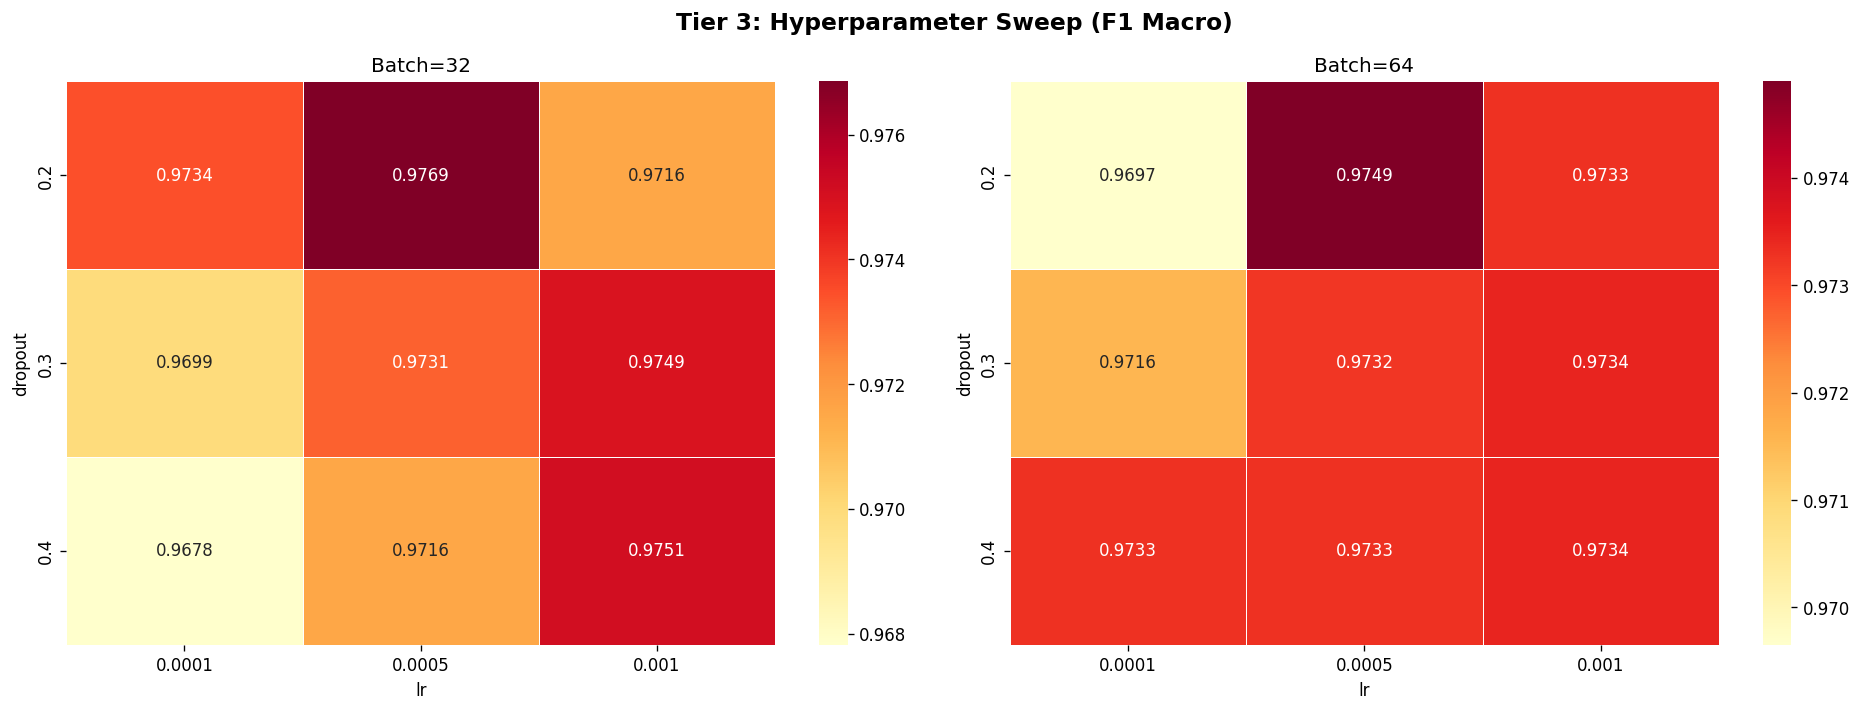

In [7]:
# VIZ 1: HP Sweep Heatmap
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Tier 3: Hyperparameter Sweep (F1 Macro)',fontsize=14,fontweight='bold')
for ax,bs,title in [(axes[0],32,'Batch=32'),(axes[1],64,'Batch=64')]:
    pivot=df_sweep[df_sweep['batch']==bs].pivot(index='dropout',columns='lr',values='f1')
    sns.heatmap(pivot,annot=True,fmt='.4f',cmap='YlOrRd',ax=ax,linewidths=0.5)
    ax.set_title(title)
plt.tight_layout()
plt.savefig('t3_plot_01_hp_sweep.png',bbox_inches='tight'); plt.show()

---
## 5-Fold CV with Best HP

In [8]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
fold_f1_full,fold_auc_full,hists_full=[],[],[]
print(f'5-fold CV FULL — lr={BEST_LR} dp={BEST_DP} bs={BEST_BS}')
for fold,(tri,vli) in enumerate(cv.split(X_full,y_full)):
    m,h=train_deep(X_full[tri],y_full[tri],X_full[vli],y_full[vli],INPUT_DIM,
                    dropout=BEST_DP,lr=BEST_LR,batch_size=BEST_BS,max_epochs=200,patience=15)
    m.eval()
    with torch.no_grad():
        p=torch.sigmoid(m(torch.tensor(X_full[vli],dtype=torch.float32).to(device))).cpu().numpy()
    f=f1_score(y_full[vli],(p>0.5).astype(int),average='macro'); a=roc_auc_score(y_full[vli],p)
    fold_f1_full.append(f); fold_auc_full.append(a); hists_full.append(h)
    print(f'  Fold {fold+1}: F1={f:.4f} AUC={a:.4f} Ep={len(h["val_f1"])}')
print(f'FULL → F1:{np.mean(fold_f1_full):.4f}±{np.std(fold_f1_full):.4f}')

5-fold CV FULL — lr=0.0005 dp=0.2 bs=32
  Fold 1: F1=0.9823 AUC=0.9962 Ep=22
  Fold 2: F1=0.9665 AUC=0.9906 Ep=29
  Fold 3: F1=0.9769 AUC=0.9893 Ep=42
  Fold 4: F1=0.9697 AUC=0.9893 Ep=54
  Fold 5: F1=0.9786 AUC=0.9910 Ep=20
FULL → F1:0.9748±0.0058


In [9]:
fold_f1_bal,fold_auc_bal,hists_bal=[],[],[]
print('5-fold CV BALANCED')
for fold,(tri,vli) in enumerate(cv.split(X_bal,y_bal)):
    m,h=train_deep(X_bal[tri],y_bal[tri],X_bal[vli],y_bal[vli],INPUT_DIM,
                    dropout=BEST_DP,lr=BEST_LR,batch_size=BEST_BS,max_epochs=200,patience=15)
    m.eval()
    with torch.no_grad():
        p=torch.sigmoid(m(torch.tensor(X_bal[vli],dtype=torch.float32).to(device))).cpu().numpy()
    f=f1_score(y_bal[vli],(p>0.5).astype(int),average='macro'); a=roc_auc_score(y_bal[vli],p)
    fold_f1_bal.append(f); fold_auc_bal.append(a); hists_bal.append(h)
    print(f'  Fold {fold+1}: F1={f:.4f} AUC={a:.4f} Ep={len(h["val_f1"])}')
print(f'BALANCED → F1:{np.mean(fold_f1_bal):.4f}±{np.std(fold_f1_bal):.4f}')

5-fold CV BALANCED
  Fold 1: F1=0.9780 AUC=0.9934 Ep=40
  Fold 2: F1=0.9902 AUC=0.9988 Ep=33
  Fold 3: F1=0.9755 AUC=0.9864 Ep=24
  Fold 4: F1=0.9804 AUC=0.9932 Ep=34
  Fold 5: F1=0.9559 AUC=0.9878 Ep=17
BALANCED → F1:0.9760±0.0112


---
## Final Hold-out + Visualizations

In [10]:
X_tr,X_te,y_tr,y_te=train_test_split(X_full,y_full,test_size=0.2,stratify=y_full,random_state=SEED)
final_m,final_h=train_deep(X_tr,y_tr,X_te,y_te,INPUT_DIM,
                             dropout=BEST_DP,lr=BEST_LR,batch_size=BEST_BS,max_epochs=200,patience=15)
final_m.eval()
with torch.no_grad():
    prob_te=torch.sigmoid(final_m(torch.tensor(X_te,dtype=torch.float32).to(device))).cpu().numpy()
pred_te=(prob_te>0.5).astype(int)
print(classification_report(y_te,pred_te,target_names=['Safe','Rugpull']))
print(f'ROC-AUC: {roc_auc_score(y_te,prob_te):.4f}')

              precision    recall  f1-score   support

        Safe       0.96      0.96      0.96       204
     Rugpull       0.98      0.98      0.98       461

    accuracy                           0.98       665
   macro avg       0.97      0.97      0.97       665
weighted avg       0.98      0.98      0.98       665

ROC-AUC: 0.9905


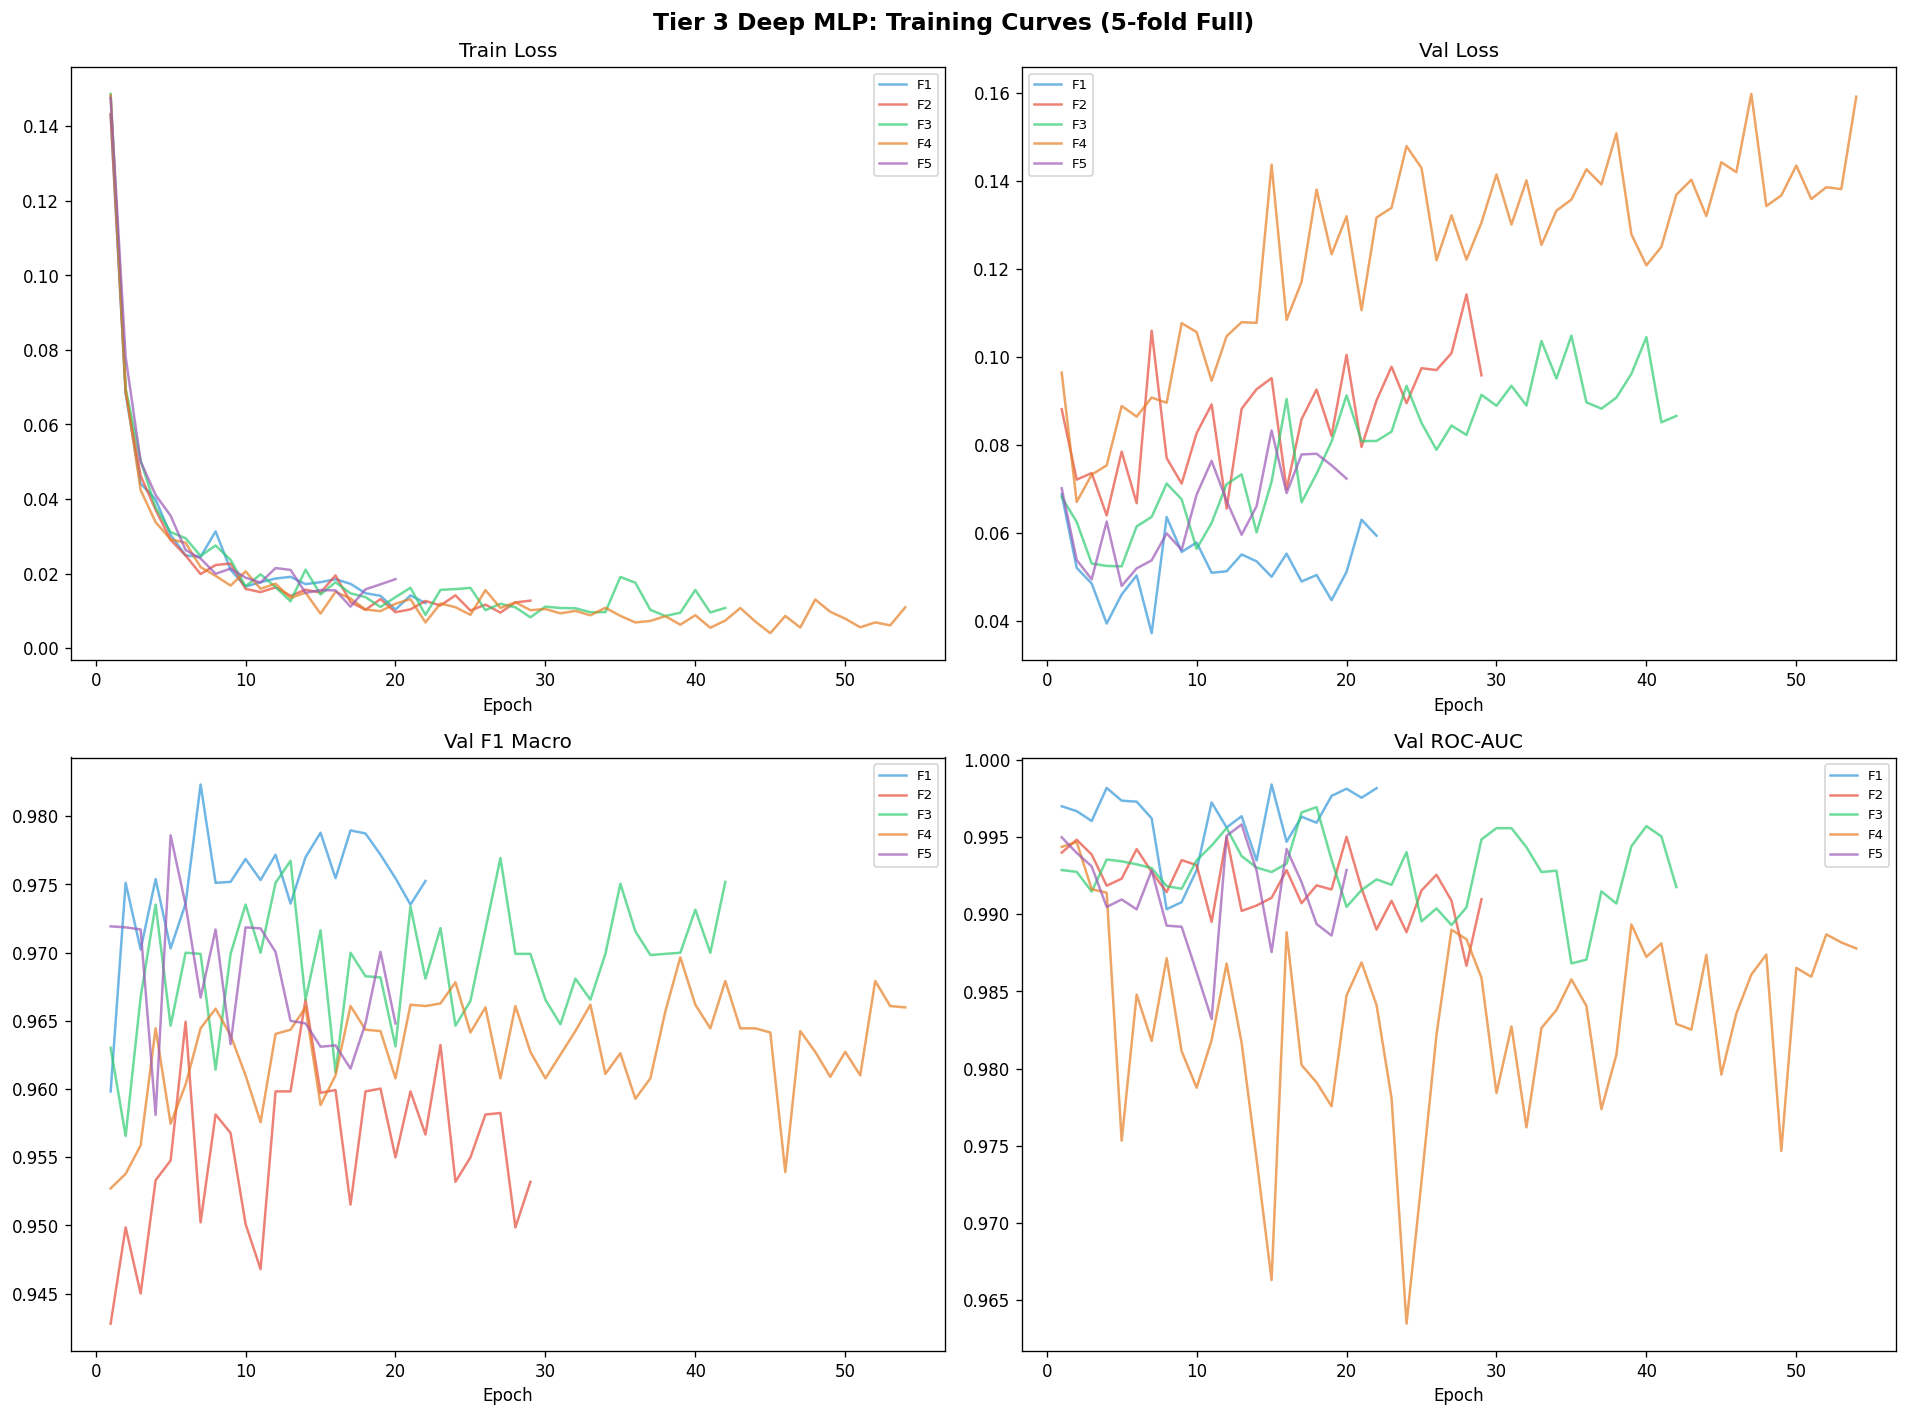

In [11]:
# VIZ 2: Full 5-fold training curves (2x2)
fold_colors=['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6']
fig,axes=plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Tier 3 Deep MLP: Training Curves (5-fold Full)',fontsize=14,fontweight='bold')
for fold,h in enumerate(hists_full):
    ep=range(1,len(h['train_loss'])+1)
    axes[0,0].plot(ep,h['train_loss'],color=fold_colors[fold],alpha=0.7,label=f'F{fold+1}')
    axes[0,1].plot(ep,h['val_loss'],  color=fold_colors[fold],alpha=0.7,label=f'F{fold+1}')
    axes[1,0].plot(ep,h['val_f1'],    color=fold_colors[fold],alpha=0.7,label=f'F{fold+1}')
    axes[1,1].plot(ep,h['val_auc'],   color=fold_colors[fold],alpha=0.7,label=f'F{fold+1}')
for ax,t in [(axes[0,0],'Train Loss'),(axes[0,1],'Val Loss'),
              (axes[1,0],'Val F1 Macro'),(axes[1,1],'Val ROC-AUC')]:
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('t3_plot_02_curves.png',bbox_inches='tight'); plt.show()

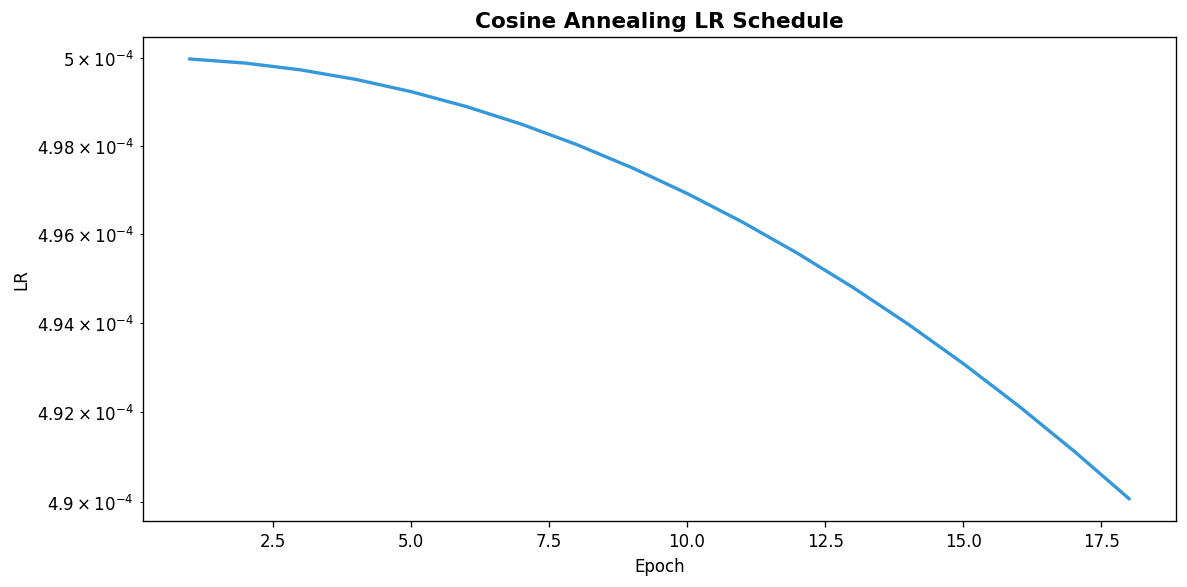

In [12]:
# VIZ 3: LR schedule
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(range(1,len(final_h['lr'])+1),final_h['lr'],color='#3498db',lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('LR'); ax.set_yscale('log')
ax.set_title('Cosine Annealing LR Schedule',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('t3_plot_03_lr_schedule.png',bbox_inches='tight'); plt.show()

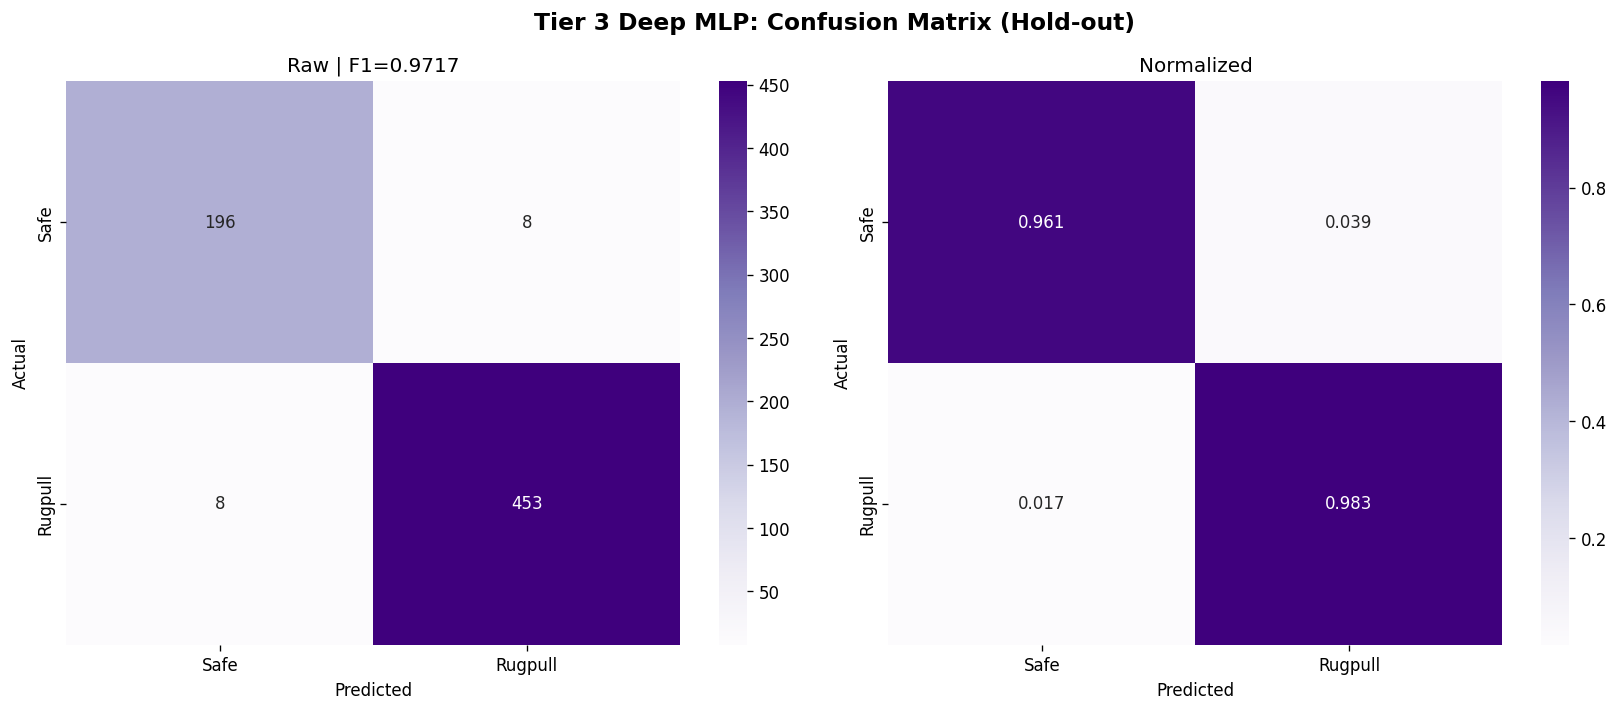

In [13]:
# VIZ 4: Confusion matrix
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Tier 3 Deep MLP: Confusion Matrix (Hold-out)',fontsize=14,fontweight='bold')
cm=confusion_matrix(y_te,pred_te)
sns.heatmap(cm,annot=True,fmt='d',cmap='Purples',ax=axes[0],
            xticklabels=['Safe','Rugpull'],yticklabels=['Safe','Rugpull'])
axes[0].set_title(f'Raw | F1={f1_score(y_te,pred_te,average="macro"):.4f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm.astype(float)/cm.sum(axis=1)[:,None],annot=True,fmt='.3f',cmap='Purples',ax=axes[1],
            xticklabels=['Safe','Rugpull'],yticklabels=['Safe','Rugpull'])
axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('t3_plot_04_confusion.png',bbox_inches='tight'); plt.show()

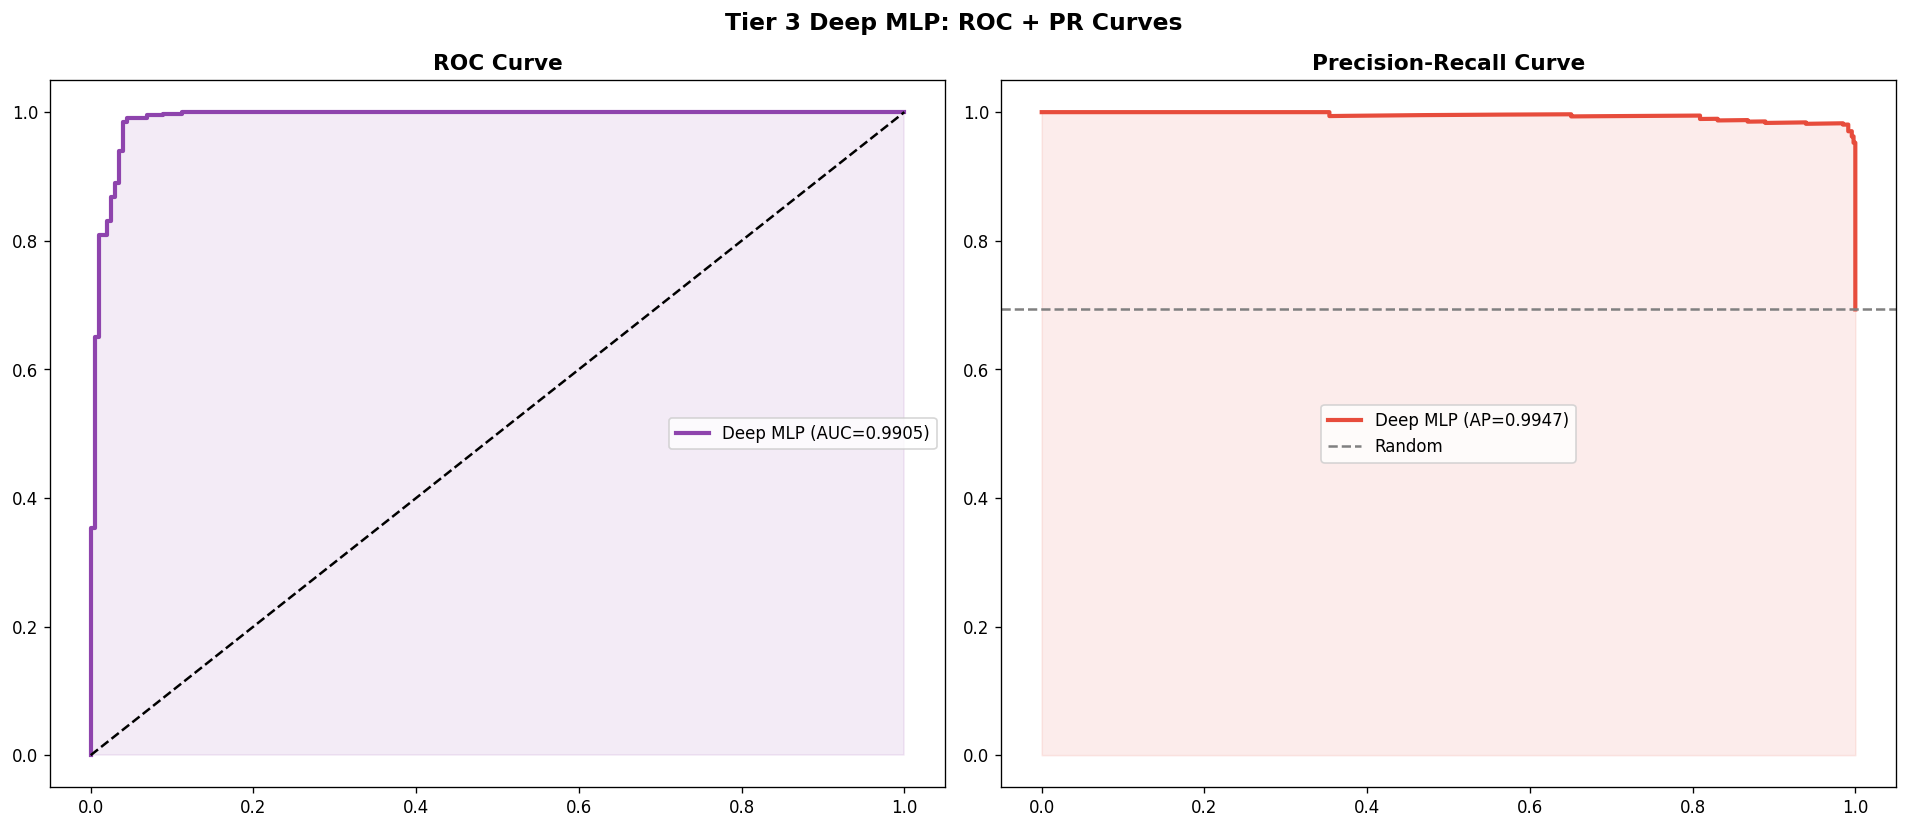

In [14]:
# VIZ 5: ROC + PR curves
fig,axes=plt.subplots(1,2,figsize=(16,7))
fpr,tpr,_=roc_curve(y_te,prob_te); auc=roc_auc_score(y_te,prob_te)
axes[0].plot(fpr,tpr,lw=2.5,color='#8e44ad',label=f'Deep MLP (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'k--'); axes[0].fill_between(fpr,tpr,alpha=0.1,color='#8e44ad')
axes[0].set_title('ROC Curve',fontsize=13,fontweight='bold'); axes[0].legend()
prec,rec,_=precision_recall_curve(y_te,prob_te); ap=average_precision_score(y_te,prob_te)
axes[1].plot(rec,prec,lw=2.5,color='#e74c3c',label=f'Deep MLP (AP={ap:.4f})')
axes[1].axhline(y_te.mean(),color='gray',linestyle='--',label='Random')
axes[1].fill_between(rec,prec,alpha=0.1,color='#e74c3c')
axes[1].set_title('Precision-Recall Curve',fontsize=13,fontweight='bold'); axes[1].legend()
fig.suptitle('Tier 3 Deep MLP: ROC + PR Curves',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('t3_plot_05_roc_pr.png',bbox_inches='tight'); plt.show()

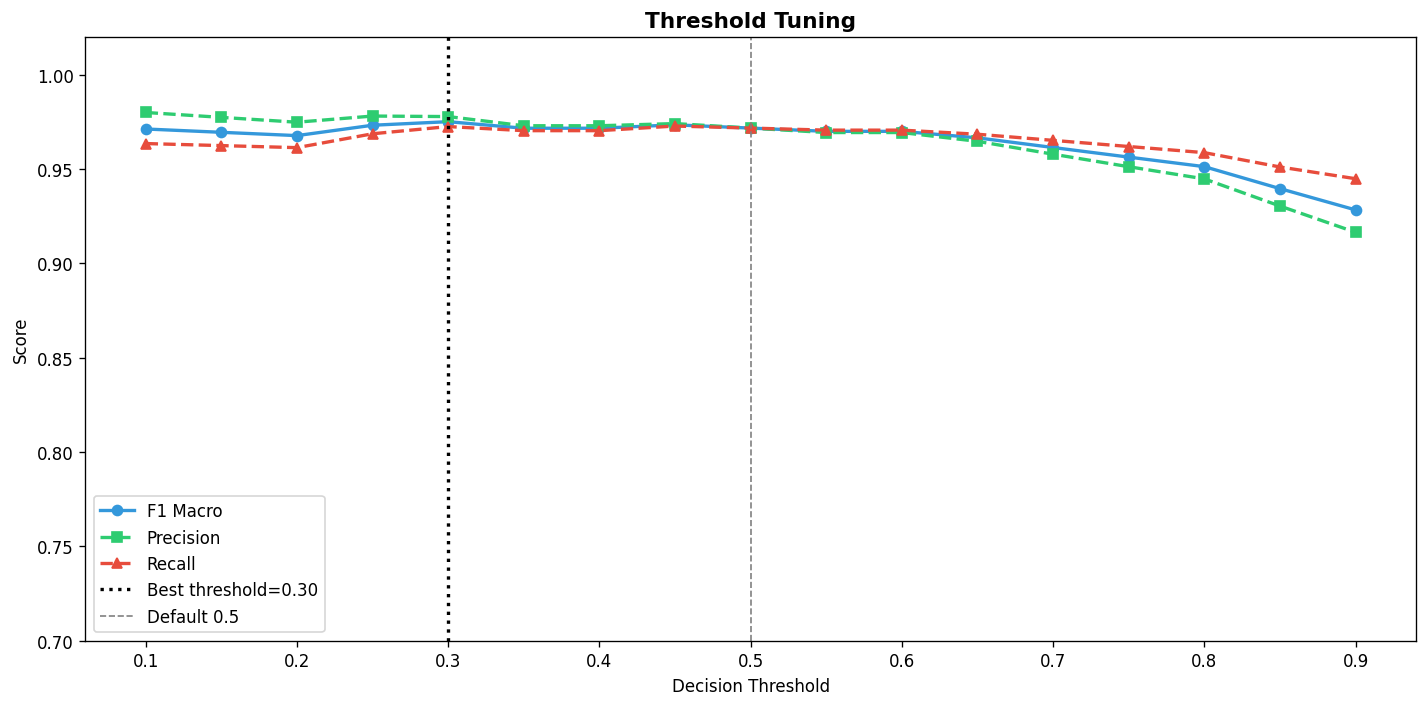

Best threshold: 0.30 → F1=0.9751


In [15]:
# VIZ 6: Threshold tuning
thresholds=np.arange(0.1,0.95,0.05)
f1s,precs,recs=[],[],[]
for th in thresholds:
    pt=(prob_te>th).astype(int)
    f1s.append(f1_score(y_te,pt,average='macro',zero_division=0))
    precs.append(precision_score(y_te,pt,average='macro',zero_division=0))
    recs.append(recall_score(y_te,pt,average='macro',zero_division=0))
best_th=thresholds[np.argmax(f1s)]
fig,ax=plt.subplots(figsize=(12,6))
ax.plot(thresholds,f1s,  'o-',color='#3498db',lw=2,ms=6,label='F1 Macro')
ax.plot(thresholds,precs,'s--',color='#2ecc71',lw=2,ms=6,label='Precision')
ax.plot(thresholds,recs, '^--',color='#e74c3c',lw=2,ms=6,label='Recall')
ax.axvline(best_th,color='black',linestyle=':',lw=2,label=f'Best threshold={best_th:.2f}')
ax.axvline(0.5,color='gray',linestyle='--',lw=1,label='Default 0.5')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score'); ax.set_ylim(0.7,1.02)
ax.set_title('Threshold Tuning',fontsize=13,fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('t3_plot_06_threshold.png',bbox_inches='tight'); plt.show()
print(f'Best threshold: {best_th:.2f} → F1={max(f1s):.4f}')

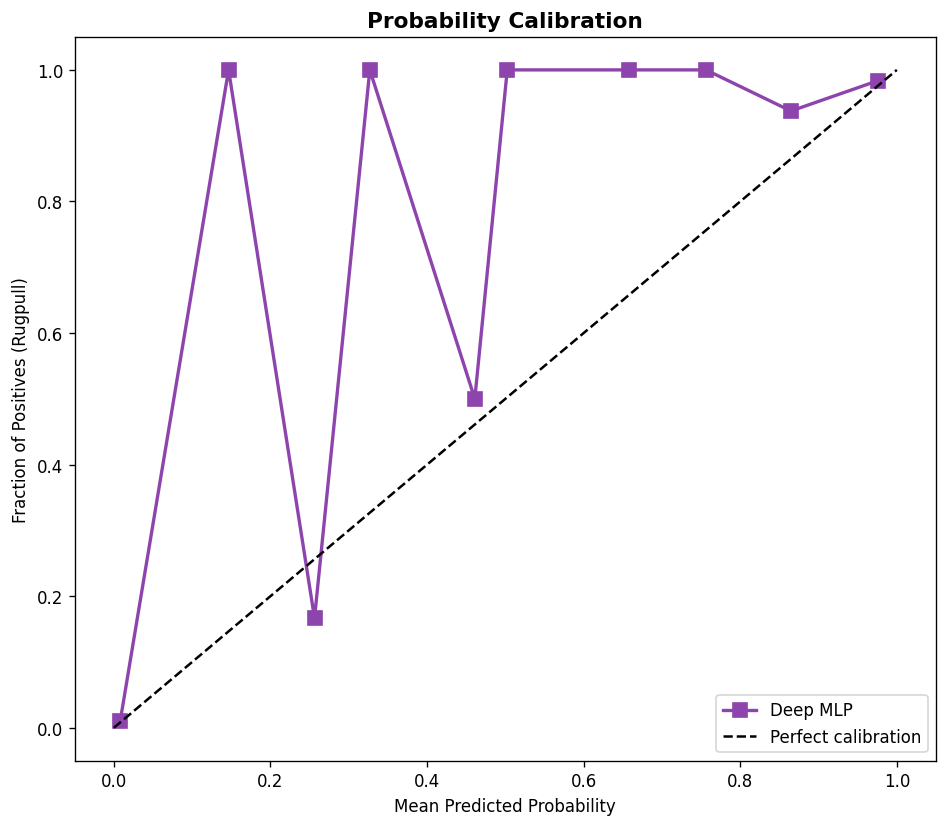

In [16]:
# VIZ 7: Calibration plot
frac_pos,mean_pred=calibration_curve(y_te,prob_te,n_bins=10)
fig,ax=plt.subplots(figsize=(8,7))
ax.plot(mean_pred,frac_pos,'s-',color='#8e44ad',lw=2,ms=8,label='Deep MLP')
ax.plot([0,1],[0,1],'k--',label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives (Rugpull)')
ax.set_title('Probability Calibration',fontsize=13,fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('t3_plot_07_calibration.png',bbox_inches='tight'); plt.show()

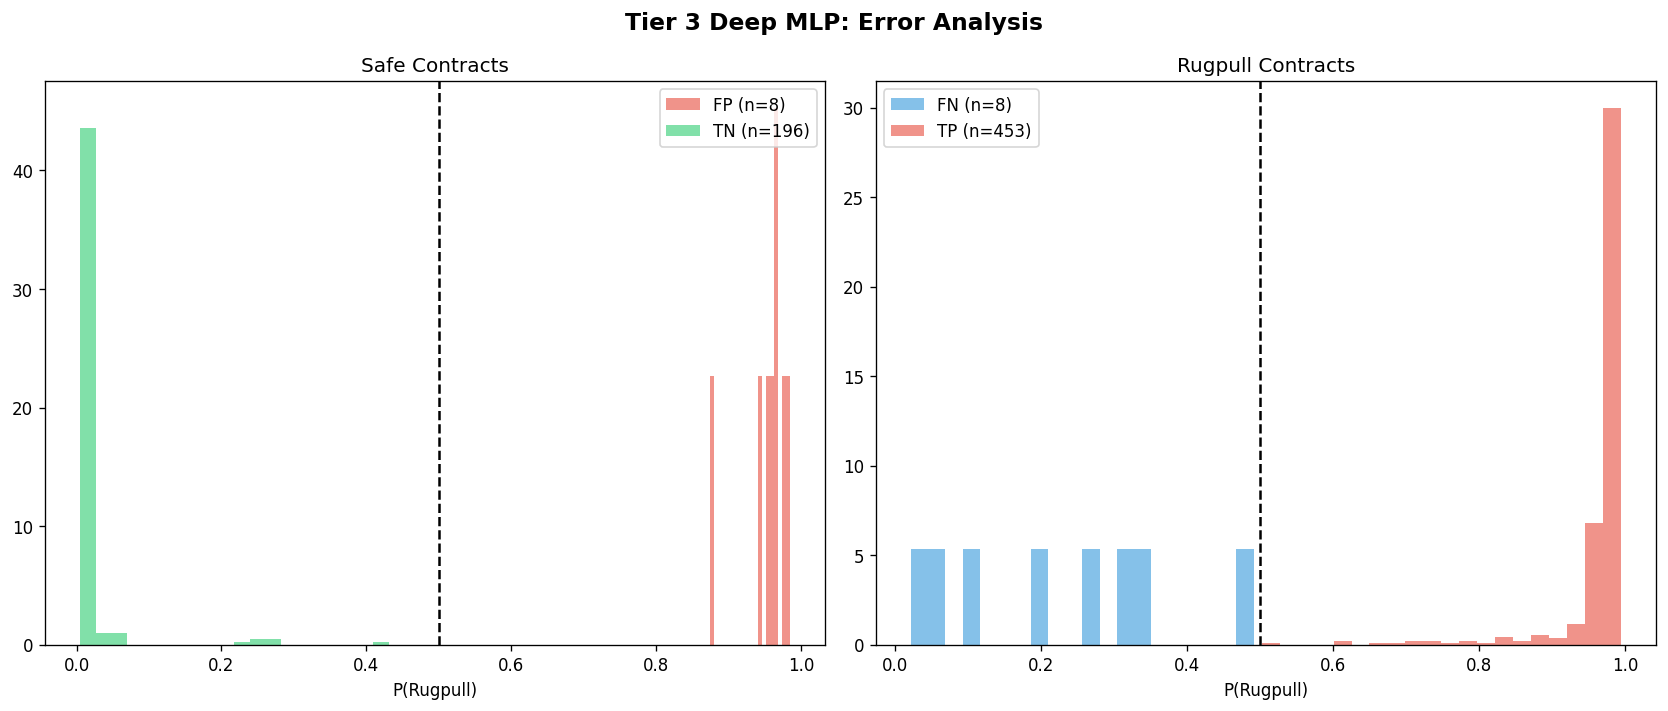

In [17]:
# VIZ 8: Error analysis
fp=(y_te==0)&(pred_te==1); fn=(y_te==1)&(pred_te==0)
tp=(y_te==1)&(pred_te==1); tn=(y_te==0)&(pred_te==0)
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Tier 3 Deep MLP: Error Analysis',fontsize=14,fontweight='bold')
for mask,color,label in [(fp,'#e74c3c',f'FP (n={fp.sum()})'),(tn,'#2ecc71',f'TN (n={tn.sum()})')]:
    axes[0].hist(prob_te[mask],bins=20,color=color,alpha=0.6,label=label,density=True)
axes[0].axvline(0.5,color='black',linestyle='--'); axes[0].set_title('Safe Contracts')
axes[0].set_xlabel('P(Rugpull)'); axes[0].legend()
for mask,color,label in [(fn,'#3498db',f'FN (n={fn.sum()})'),(tp,'#e74c3c',f'TP (n={tp.sum()})')]:
    axes[1].hist(prob_te[mask],bins=20,color=color,alpha=0.6,label=label,density=True)
axes[1].axvline(0.5,color='black',linestyle='--'); axes[1].set_title('Rugpull Contracts')
axes[1].set_xlabel('P(Rugpull)'); axes[1].legend()
plt.tight_layout()
plt.savefig('t3_plot_08_error_analysis.png',bbox_inches='tight'); plt.show()

In [18]:
tier3_raw={'DeepMLP':{
    'best_hp':{'lr':BEST_LR,'dropout':BEST_DP,'batch':BEST_BS},
    'full_f1_mean':float(np.mean(fold_f1_full)),'full_f1_std':float(np.std(fold_f1_full)),
    'full_auc_mean':float(np.mean(fold_auc_full)),
    'bal_f1_mean':float(np.mean(fold_f1_bal)),'bal_auc_mean':float(np.mean(fold_auc_bal)),
    'holdout_f1':float(f1_score(y_te,pred_te,average='macro')),
    'holdout_auc':float(roc_auc_score(y_te,prob_te)),
    'best_threshold':float(best_th)
}}
with open('tier3_raw_results.json','w') as f: json.dump(tier3_raw,f,indent=2)
torch.save(final_m.state_dict(),'deep_mlp_best_model.pt')
print('Saved: tier3_raw_results.json | deep_mlp_best_model.pt')
print('=== TIER 3 COMPLETE ===')

Saved: tier3_raw_results.json | deep_mlp_best_model.pt
=== TIER 3 COMPLETE ===
